# Проект для "Викишоп" с BERT

## Описание проекта

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 
Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.
Постройте модель со значением метрики качества **F1 не меньше 0.75**. 

## Подключение библиотек

In [1]:
pip install transformers torch -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import transformers
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from tqdm import notebook #отображение индикатора прогресса
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from catboost import CatBoostRegressor
from sklearn.metrics import f1_score, make_scorer

In [4]:
RANDOM_STATE = 42

## Подготовка данных

In [5]:
try:
    df = pd.read_csv('toxic_comments.csv')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')

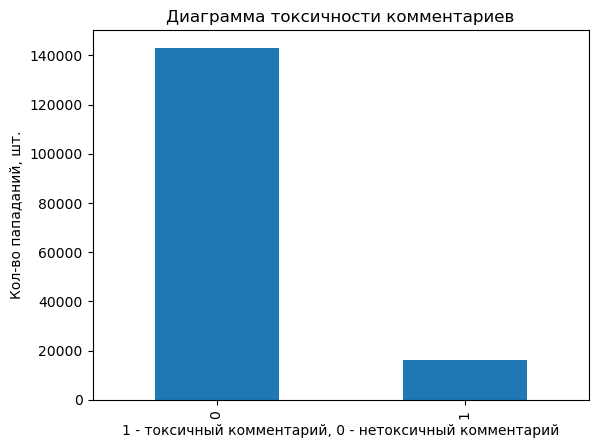

In [6]:
df['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

Для ускорения создания эмбеддингов и устранения дисбаланса возьмем из выборки по 500 случайных элементов каждого вида

In [7]:
df_0 = df.query('toxic == 0').sample(500, random_state=RANDOM_STATE)

In [8]:
df_1 = df.query('toxic == 1').sample(500, random_state=RANDOM_STATE)

In [9]:
df = pd.concat([df_0, df_1])

In [10]:
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [11]:
df.head(5)

,Unnamed: 0,text,toxic
0,104306,GUY THAT SLEEPS WITH HIS MOTHER,1
1,148815,FC*K U\n\nWhy the fc*k should I get a warning ...,1
2,99080,"""\n\nTalking about useless shit constantly on ...",1
3,16721,Your mom plays gay music.. linkin park is the ...,1
4,28798,thanks a lot \n\ni can edit now,0


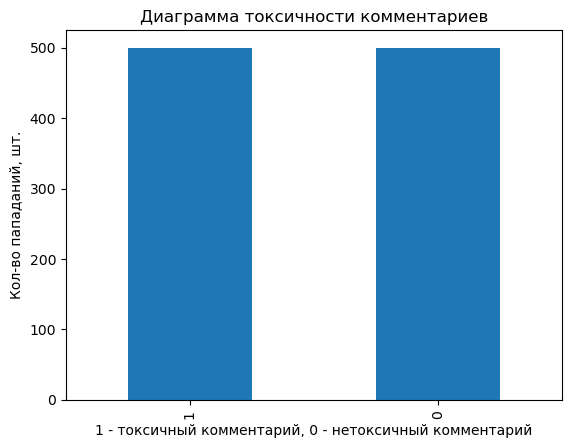

In [12]:
df['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

Дисбаланс классов устранен

Комментарии на англ. языке, поэтому будем использовать BERT для англ. языка

In [13]:
df = df[['text', 'toxic']]

In [14]:
df.head(1)

,text,toxic
0,GUY THAT SLEEPS WITH HIS MOTHER,1


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1000 non-null   object
 1   toxic   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [16]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')

In [17]:
tokenized = df['text'].apply(
    lambda x: tokenizer.encode(x, add_special_tokens=True, max_length=512, truncation=True)
)

In [18]:
tokenized.head(1).values

array([list([101, 3124, 2008, 25126, 2007, 2010, 2388, 102])],
      dtype=object)

In [19]:
max_len = 0
for i in tokenized.values:
    if max_len < len(i):
        max_len = len(i)
max_len

512

In [20]:
padded = np.array([i + [0] * (max_len - len(i)) for i in tokenized.values])

In [21]:
padded[0]

array([  101,  3124,  2008, 25126,  2007,  2010,  2388,   102,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

In [22]:
len(padded[0])

512

In [23]:
attention_mask = np.where(padded != 0, 1, 0)

In [24]:
attention_mask[0]

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [25]:
#config = transformers.BertConfig.from_json_file('config.json')
try:
    model = transformers.BertModel.from_pretrained('pytorch_model.bin')
except:
    model = transformers.BertModel.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
batch_size = 100
embeddings = []

for i in notebook.tqdm(range(padded.shape[0] // batch_size)):
    batch = torch.LongTensor(padded[batch_size * i : batch_size * (i + 1)]) 
    attention_mask_batch = torch.LongTensor(attention_mask[batch_size * i : batch_size * (i + 1)])
        
    with torch.no_grad():
        batch_embeddings = model(batch, attention_mask=attention_mask_batch)
        
    embeddings.append(batch_embeddings[0][:,0,:].numpy())

  0%|          | 0/10 [00:00<?, ?it/s]

In [27]:
features = np.concatenate(embeddings)

In [28]:
features.shape

(1000, 768)

## Построение предсказательных моделей

In [29]:
X_train, X_test, y_train, y_test = train_test_split(features, df['toxic'], random_state=RANDOM_STATE, stratify=df['toxic'])

In [30]:
pipe_final = Pipeline(
    [
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [31]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)]
    },

    {
        'models': [LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)]
    },

    {
        'models': [SVC(random_state=RANDOM_STATE)],
        'models__kernel': ['rbf', 'linear', 'poly'],
        'models__degree': range(3, 5)
    }
]

In [32]:
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    n_jobs=-1,
    scoring='f1'
)

In [33]:
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('models',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [DecisionTreeClassifier(random_state=42)]},
                         {'models': [LogisticRegression(max_iter=1000,
                                                        random_state=42)]},
                         {'models': [SVC(random_state=42)],
                          'models__degree': range(3, 5),
                          'models__kernel': ['rbf', 'linear', 'poly']}],
             scoring='f1')

In [34]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__degree,param_models__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.518208,0.042839,0.005112,0.000893,DecisionTreeClassifier(random_state=42),NaN,NaN,{'models': DecisionTreeClassifier(random_state...,0.698630,0.658065,0.693878,0.614286,0.613333,0.655638,0.036922,8
1,0.178919,0.040769,0.004600,0.000800,"LogisticRegression(max_iter=1000, random_state...",NaN,NaN,"{'models': LogisticRegression(max_iter=1000, r...",0.853503,0.864516,0.871795,0.847682,0.759124,0.839324,0.040968,1
2,0.141121,0.034161,0.055421,0.006145,SVC(random_state=42),3.0,rbf,"{'models': SVC(random_state=42), 'models__degr...",0.853333,0.826667,0.834437,0.841379,0.811594,0.833482,0.014021,2
3,0.091435,0.014584,0.014702,0.003736,SVC(random_state=42),3.0,linear,"{'models': SVC(random_state=42), 'models__degr...",0.833333,0.831169,0.850000,0.831169,0.762590,0.821652,0.030363,6
4,0.132231,0.026925,0.024913,0.006209,SVC(random_state=42),3.0,poly,"{'models': SVC(random_state=42), 'models__degr...",0.845638,0.843537,0.818792,0.845070,0.794118,0.829431,0.020330,5
5,0.233341,0.043708,0.070198,0.015510,SVC(random_state=42),4.0,rbf,"{'models': SVC(random_state=42), 'models__degr...",0.853333,0.826667,0.834437,0.841379,0.811594,0.833482,0.014021,2
6,0.208411,0.014200,0.017600,0.002652,SVC(random_state=42),4.0,linear,"{'models': SVC(random_state=42), 'models__degr...",0.833333,0.831169,0.850000,0.831169,0.762590,0.821652,0.030363,6
7,0.168602,0.035832,0.012001,0.002964,SVC(random_state=42),4.0,poly,"{'models': SVC(random_state=42), 'models__degr...",0.845638,0.849315,0.818792,0.843537,0.794118,0.830280,0.021041,4


In [35]:
f1_best = grid_search.best_score_

In [36]:
print('Среднее значение метрики F1 на валидационной выборке', f1_best)

Среднее значение метрики F1 на валидационной выборке 0.8393240784674088


In [37]:
f1_test = f1_score(y_test, grid_search.predict(X_test))

In [38]:
print('Среднее значение метрики F1 на тестовой выборке', f1_test)

Среднее значение метрики F1 на тестовой выборке 0.8806584362139918


## Вывод

Среднее значение метрики F1 на валидационной выборке на модели BERT составляет 0.84, что удовлетворяет требованию Заказчика